In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

#from src.bargaining_analysis.helper import set_plot_theme, finalize_plot


In [2]:

COLOR_SCHEME=["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"]
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
sns.set_style("white")



In [3]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full.csv")

## Micro Evidence Block

In [4]:
def plot_bargotiation_rounds_by_id(df_clean, negotiation_ids, max_offers=10):
    """
    Plot specified negotiations by their negotiation_id, with micro-step arrows
    and a dotted line marking the end of bargaining.
    
    Parameters:
    -----------
    df_clean : pandas.DataFrame
        The cleaned bargaining data. Must include columns:
        'negotiation_id', 'participant_role', 'offer_<i>', 'offer_time_<i>',
        'termination_time_sec', 'valuation', 'bargaining_outcome'
    negotiation_ids : list
        List of negotiation_id values to plot (e.g. length 4).
    max_offers : int
        Maximum number of offers recorded (default=10).
    """
    
    # Filter to only the specified negotiation IDs
    df_sel = df_clean[df_clean['negotiation_id'].isin(negotiation_ids)]
    
    # Layout: try for square-ish grid
    n = len(negotiation_ids)
    rows = cols = int(math.ceil(math.sqrt(n)))
    fig, axes = plt.subplots(rows, cols,
                              figsize=(5 * cols, 4 * rows),
                              squeeze=False)
    
    # Precompute global max for consistent y-axis
    all_off_vals = []
    for nid in negotiation_ids:
        part = df_sel[df_sel['negotiation_id'] == nid]
        for role in ('Buyer', 'Seller'):
            row = part[part['participant_role'] == role]
            if row.empty:
                continue
            for i in range(1, max_offers + 1):
                col = f'offer_{i}'
                if col in row:
                    val = row[col].iloc[0]
                    if pd.notna(val):
                        all_off_vals.append(val)
    y_max = max(all_off_vals) * 1.1 if all_off_vals else 1
    
    # Plot each negotiation by ID
    for idx, nid in enumerate(negotiation_ids):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        
        part = df_sel[df_sel['negotiation_id'] == nid]
        buyer = part[part['participant_role'] == 'Buyer'].iloc[0]
        seller = part[part['participant_role'] == 'Seller'].iloc[0]
        
        def get_series(p, color, role):
            times, offers = [], []
            for i in range(1, max_offers + 1):
                t = p.get(f'offer_time_{i}', np.nan)
                o = p.get(f'offer_{i}', np.nan)
                if pd.notna(t) and pd.notna(o):
                    times.append(t)
                    offers.append(o)
                    ax.scatter(t, o, color=color, alpha=0.7,
                               label=role if i == 1 else "")
            return times, offers
        
        bt, bo = get_series(buyer, 'blue', 'Buyer')
        st, so = get_series(seller, 'red', 'Seller')
        
        # connecting dashed lines
        if bt:
            ax.plot(bt, bo, '--', color='blue', alpha=0.3)
        if st:
            ax.plot(st, so, '--', color='red', alpha=0.3)
        
        # micro-arrows
        for times, offs, col in [(bt, bo, 'blue'), (st, so, 'red')]:
            for i in range(1, len(times)):
                ax.annotate(
                    '',
                    xy=(times[i], offs[i]),
                    xytext=(times[i - 1], offs[i - 1]),
                    arrowprops=dict(
                        arrowstyle='->',
                        linestyle=':',
                        color=col,
                        alpha=0.6,
                        linewidth=1
                    )
                )
        
        # end-line
        term_times = [
            t for t in (
                buyer.get('termination_time_sec'),
                seller.get('termination_time_sec')
            ) if pd.notna(t)
        ]
        t_end = max(term_times) if term_times else max(bt + st, default=0)
        ax.axvline(t_end, linestyle=':', linewidth=1.5, color='black')
        ax.text(
            t_end,
            y_max * 0.95,
            'End',
            rotation=90,
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6)
        )
        
        # valuations box
        ax.text(
            0.02, 0.98,
            (f'Buyer Valuation: {buyer["valuation"]}, '
             f'Seller Valuation: {seller["valuation"]}\n'
             f'Outcome: {buyer["bargaining_outcome"]}'),
            transform=ax.transAxes,
            va='top',
            fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8)
        )
        
        ax.set_title(f'Negotiation {nid}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Offer')
        ax.set_ylim(0, y_max)
        ax.grid(alpha=0.3)
        ax.legend(loc='lower right', fontsize=7)
       
    # Hide any unused subplots
    for idx in range(len(negotiation_ids), rows * cols):
        r = idx // cols
        c = idx % cols
        axes[r][c].set_visible(False)
    
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

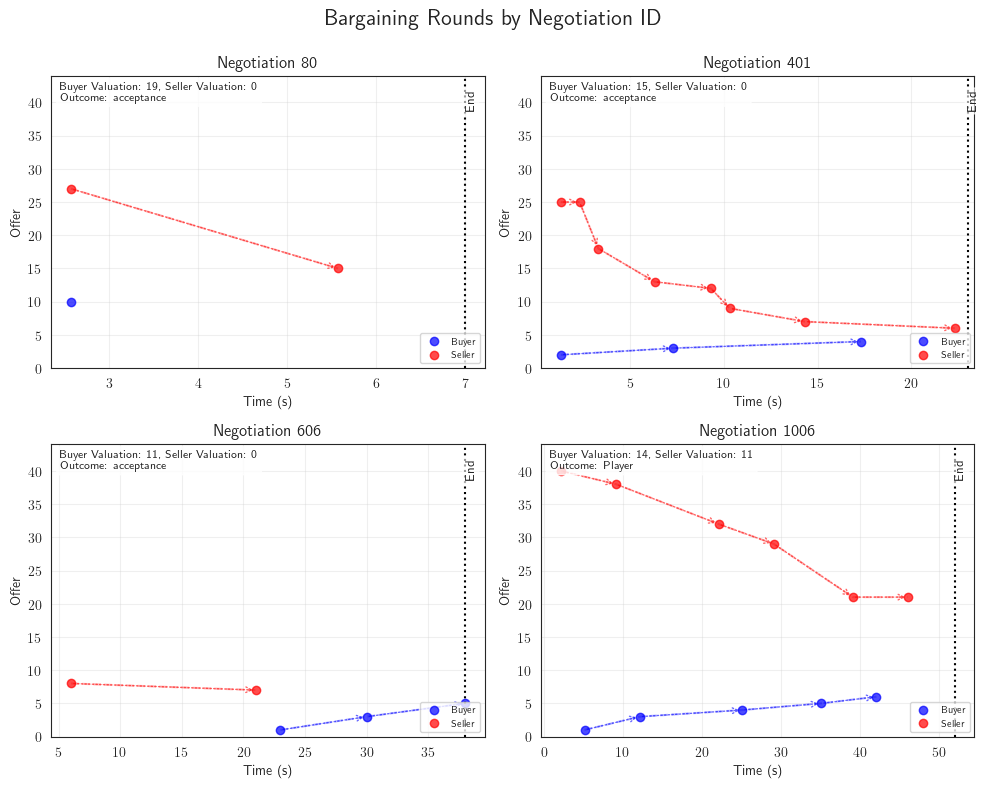

In [9]:
negotiation_ids = [80, 401, 606, 1006]
fig = plot_bargotiation_rounds_by_id(df, negotiation_ids, max_offers=10)
fig.suptitle('Bargaining Rounds by Negotiation ID', fontsize=16)
plt.show()

## Look at plausibility

In [4]:
negative_duration_count = (df['bargaining_time_full_sec'] >100 ).sum()
print(f"Number of entries with negative bargaining_duration: {negative_duration_count}")


Number of entries with negative bargaining_duration: 56


In [5]:
df_error = df[df['bargaining_time_full_sec'] > 100]

In [6]:
df_error['bargaining_time_full_sec'].mean()

np.float64(129.17857142857142)

## Plot Bargaining Rounds

In [7]:
df_session = df[df["session_id"] == "1a8klj6g"]

In [8]:
def plot_bargaining_rounds(df_clean, round1, round2, n_samples=4, max_offers=10, random_state=None):
    """
    Plot n_samples randomly selected negotiations from two rounds, with micro-step arrows
    and a dotted line marking the end of bargaining.

    Parameters:
    -----------
    df_clean : pandas.DataFrame
        The cleaned bargaining data.
    round1 : int
        First round to sample from.
    round2 : int
        Second round to sample from.
    n_samples : int
        Number of negotiations to randomly select (default=4).
    max_offers : int
        Maximum number of offers recorded (default=10).
    random_state : int or None
        Seed for reproducibility.
    """
    # fix randomness
    rng = np.random.default_rng(random_state)

    # restrict to the two rounds
    df_rounds = df_clean[df_clean['round'].isin([round1, round2])]

    # build list of unique (round, group_id) tuples
    combos = df_rounds[['round', 'group_id_in_round']]\
             .drop_duplicates()\
             .apply(tuple, axis=1)\
             .tolist()

    # sample up to n_samples
    sampled = rng.choice(combos, size=min(n_samples, len(combos)), replace=False)

    # layout: 2 rows × 2 columns
    rows = cols = int(math.ceil(math.sqrt(len(sampled))))
    fig, axes = plt.subplots(rows, cols,
                              figsize=(5*cols, 4*rows),
                              squeeze=False)
    plt.rcParams['text.usetex'] = False
    fig.suptitle(f'Random Sample of {len(sampled)} Negotiations\n'
                 f'Rounds {round1} & {round2}', fontsize=16)

    # precompute global max for consistent y-axis
    all_off_vals = []
    for rnd, gid in sampled:
        part = df_rounds[(df_rounds['round']==rnd) & (df_rounds['group_id_in_round']==gid)]
        for role in ('Buyer','Seller'):
            row = part[part['participant_role']==role]
            for i in range(1, max_offers+1):
                val = row[f'offer_{i}'].iloc[0] if f'offer_{i}' in row else np.nan
                if pd.notna(val):
                    all_off_vals.append(val)
    y_max = max(all_off_vals)*1.1 if all_off_vals else 1

    # plot each sampled negotiation
    for idx, (rnd, gid) in enumerate(sampled):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]

        part = df_rounds[(df_rounds['round']==rnd) & (df_rounds['group_id_in_round']==gid)]
        buyer = part[part['participant_role']=='Buyer'].iloc[0]
        seller = part[part['participant_role']=='Seller'].iloc[0]

        def get_series(p, color, role):
            times, offers = [], []
            for i in range(1, max_offers+1):
                t = p.get(f'offer_time_{i}', np.nan)
                o = p.get(f'offer_{i}', np.nan)
                if pd.notna(t) and pd.notna(o):
                    times.append(t)
                    offers.append(o)
                    ax.scatter(t, o, color=color, alpha=0.7,
                               label=f'{role}' if i==1 else "")
            return times, offers

        bt, bo = get_series(buyer, 'blue', 'Buyer')
        st, so = get_series(seller, 'red', 'Seller')

        # connecting dashed lines
        if bt: ax.plot(bt, bo, '--', color='blue', alpha=0.3)
        if st: ax.plot(st, so, '--', color='red',  alpha=0.3)

        # micro-arrows
        for times, offs, col in [(bt, bo, 'blue'), (st, so, 'red')]:
            for i in range(1, len(times)):
                ax.annotate('', xy=(times[i], offs[i]),
                            xytext=(times[i-1], offs[i-1]),
                            arrowprops=dict(arrowstyle='->',
                                            linestyle=':',
                                            color=col,
                                            alpha=0.6,
                                            linewidth=1))

        # end-line
        term_times = [t for t in (buyer.get('termination_time_sec'),
                                   seller.get('termination_time_sec')) if pd.notna(t)]
        t_end = max(term_times) if term_times else max(bt+st, default=0)
        ax.axvline(t_end, linestyle=':', linewidth=1.5, color='black')
        ax.text(t_end, y_max*0.95, 'End', rotation=90,
                va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

        # valuations box
        ax.text(0.02, 0.98,
                f'Buyer Valuation: {buyer["valuation"]}, Seller Valuation: {seller["valuation"]}\n'
                f'Outcome: {"Player Termination" if buyer["bargaining_outcome"] == "Player" else buyer["bargaining_outcome"]}',
                transform=ax.transAxes, va='top',
                fontsize=8,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Offer')
        ax.set_ylim(0, y_max)
        ax.grid(alpha=0.3)
        ax.legend(loc='lower right', fontsize=7)  # Moved legend to bottom right

    # hide any unused subplots
    total = rows*cols
    for idx in range(len(sampled), total):
        r = idx // cols
        c = idx % cols
        axes[r][c].set_visible(False)

    plt.tight_layout(rect=[0,0,1,0.94])
    plt.show()

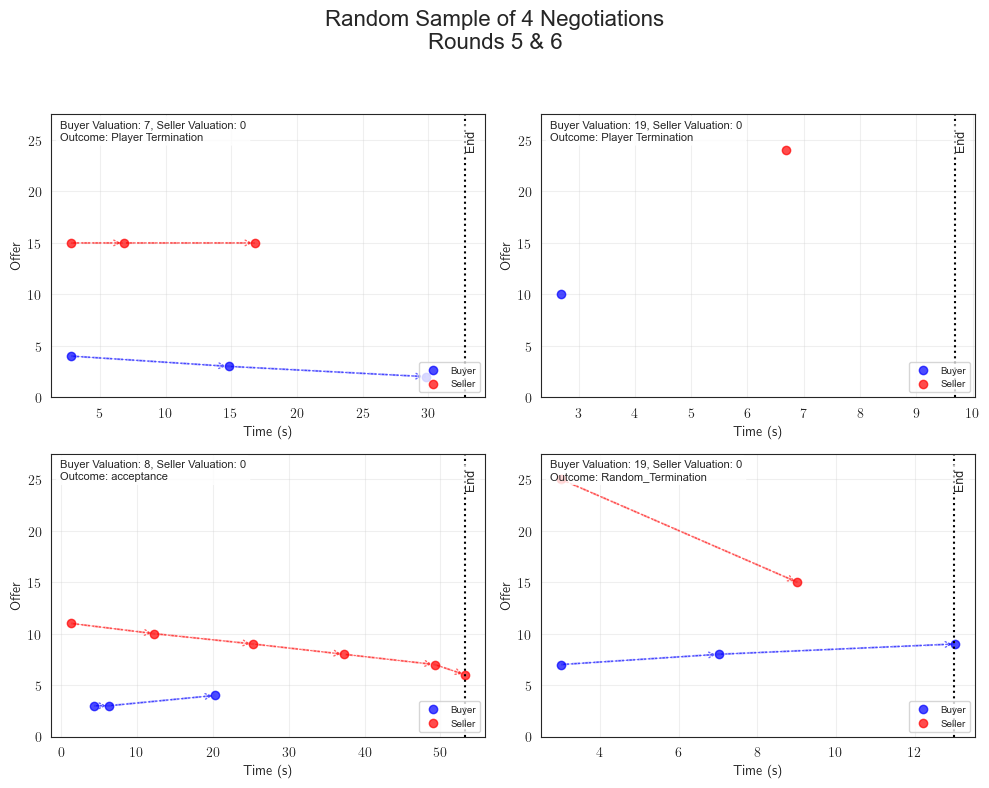

In [9]:
plot_bargaining_rounds(df_session, 5, 6, random_state=55)

In [10]:
df_t3 = df[df["treatment"] == "T3"]

In [11]:
df_t3_33 = df_t3[df_t3["round"] == 33]

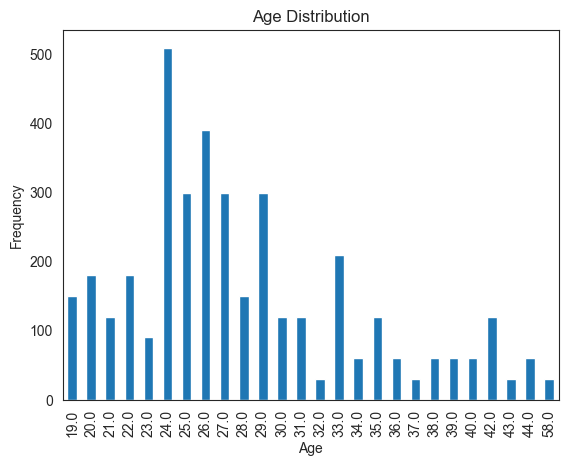

In [15]:
df["age"].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [6]:
df_high = df[df['payoff'] > 28]

In [3]:
#Buyer Valuatios
one_sided = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/environment_data/participant_data_1_groups_one-sided.pkl")

In [4]:
buyer_vals = one_sided[one_sided['Role'] == 'Buyer']['Valuation']



In [5]:
all_valuations = buyer_vals.explode().values

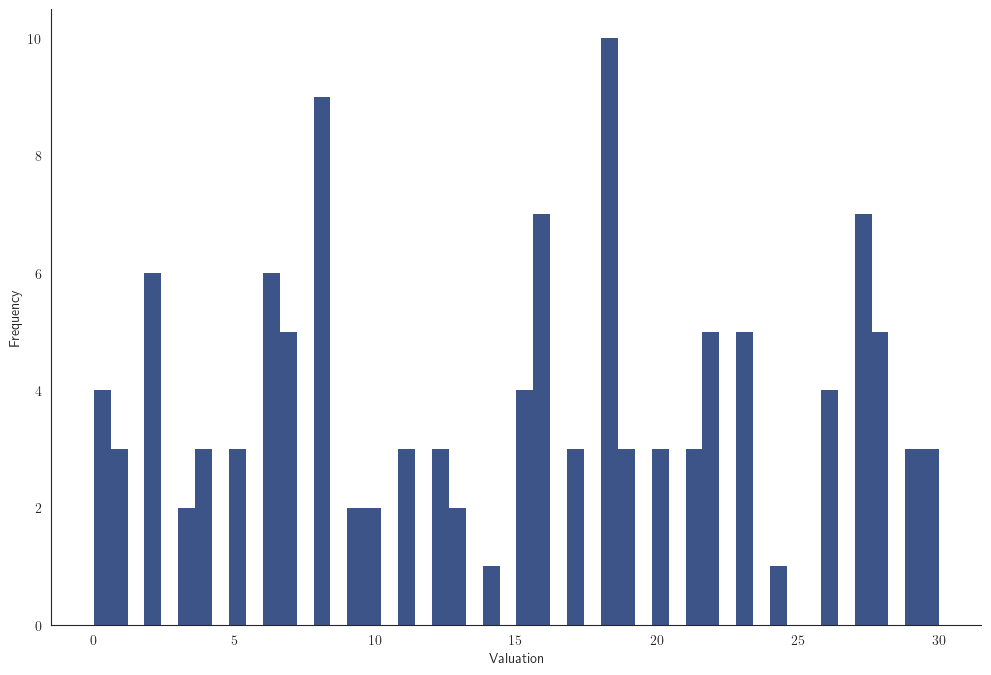

In [6]:
plt.figure(figsize=(12, 8))
plt.hist(all_valuations, bins=50, edgecolor='none', color=COLOR_SCHEME[0] )
plt.xlabel('Valuation')
plt.ylabel('Frequency')
plt.grid(False)
sns.despine()
plt.show()

In [7]:
two_sided = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/environment_data/participant_data_1_groups_two-sided.pkl")

In [8]:
buyer_vals = two_sided[two_sided['Role'] == 'Buyer']['Valuation']
all_buyer_vals =  buyer_vals.explode().values

seller_vals = two_sided[two_sided['Role'] == 'Seller']['Valuation']
all_seller_vals = seller_vals.explode().values

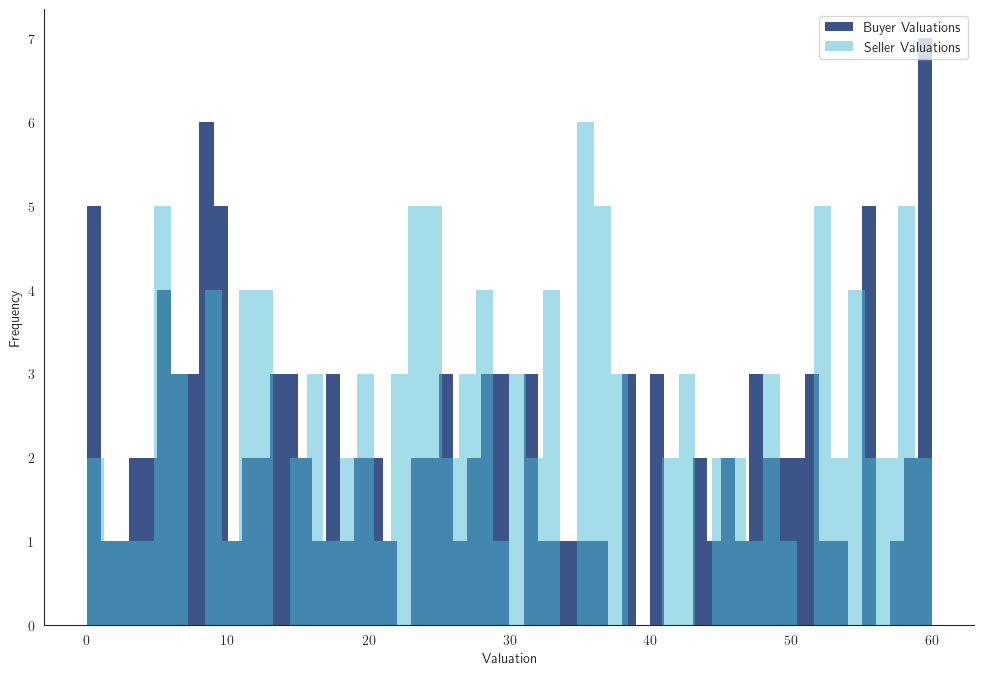

In [10]:
plt.figure(figsize=(12, 8))

# Plot histogram for buyer valuations
plt.hist(all_buyer_vals, bins=60, label='Buyer Valuations', edgecolor='none', color=COLOR_SCHEME[0])

# Plot histogram for seller valuations
plt.hist(all_seller_vals, bins=50, alpha=0.5,  label='Seller Valuations', edgecolor='none', color=COLOR_SCHEME[2])

plt.xlabel('Valuation')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(False)
sns.despine()
plt.show()
